In [1]:
import glob
import ast
import time
import numpy as np
import pandas as pd
from tqdm import tqdm 
import cv2
import json
import collections
from PIL import Image
import re
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import zipfile

from tqdm import tqdm
import shutil

np.random.seed(42)

In [2]:
import warnings
warnings.filterwarnings('ignore')

### Loading package

In [3]:
import sys
from pathlib import Path

here_path = Path().resolve()
repo_path = here_path.parents[1]
sys.path.append(str(repo_path))

In [4]:
from py.utils import verifyDir,verifyFile, verifyDataFrame

In [5]:
from py.config import Config

cfg = Config()

np.random.seed(cfg.RANDOM_STATE)
cfg.DATA_PATH, cfg.MODEL_PATH

('/media/felipe/DATA19/datasets/', '/media/felipe/DATA19/models/')

In [6]:
QSCORE_PATH=f"{cfg.DATA_PATH}pp2/Qscores/"
IMAGES_PATH = f"{cfg.DATA_PATH}pp2/images/"

In [7]:
MODEL_DIR = f"{cfg.MODEL_PATH}"
MODEL_DIR += f"{cfg.SEG_DATASET}_upd4k" if cfg.USE_UPD else f"{cfg.SEG_DATASET}"
MODEL_DIR += "_group/" if cfg.BY_GROUPS else "/"
MODEL_DIR += "" if cfg.USE_UPD else f"{cfg.SEG_MODEL_NAME}/"
MODEL_DIR += f"{cfg.ML_TASK}/"
MODEL_DIR

'/media/felipe/DATA19/models/ade20k_upd4k_group/classifications/'

In [8]:
OUT_NAME = f"{cfg.PRECEPTION_METRIC}"
OUT_NAME += "_filter" if cfg.FILTER_FEATURES else ""
OUT_NAME += "_bin" if cfg.BINARIZE_FEATURES else ""
OUT_NAME

'safety'

In [9]:
CF_DIR = MODEL_DIR.replace(f"{cfg.ML_TASK}/", f"counterfactuals/{OUT_NAME}/")
CF_DIR

'/media/felipe/DATA19/models/ade20k_upd4k_group/counterfactuals/safety/'

In [10]:
verifyDir(CF_DIR)

### Loading Data and Models

In [11]:
from py.datasets import UrbanPhysicalDisorder

UPD_DATASET = f"{cfg.SEG_DATASET}_upd4k" if cfg.USE_UPD else cfg.SEG_DATASET

uss = UrbanPhysicalDisorder(data_path=cfg.DATA_PATH)
uss.generate_dataset(dataset=f"{UPD_DATASET}")

In [12]:
data_df = pd.read_csv(f"{MODEL_DIR}{OUT_NAME}_data.csv", sep=";", low_memory=False)

In [13]:
label_map = dict( zip( data_df['target'], data_df['label'] ) )
label_map

{1: 'safety', 0: 'not safety'}

### Loading model

In [14]:
model_grid = joblib.load(f'{MODEL_DIR}{OUT_NAME}_best.pkl')
model_grid

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__bootstrap': [True], 'classifier__max_depth': [20], 'classifier__max_features': [None], 'classifier__min_samples_leaf': [3], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo...shuffle=False)
,"verbose verbose: intControls the verbosity: the higher, the more me

# CounterFactual Explanations

In short, Wachter et al.'s method minimizes the loss:

$L(x, x', y', \lambda) = \lambda . (\hat{f}(x') - y')^2 + d(x, x')$

* The first term $\lambda . (\hat{f}(x') - y')^2$ minimizes the squared difference between the model prediction for the counterfactual $x'$, i.e., $\hat{f}(x')$ and the desired prediction (specified by the user) $y'$.  
   Note that $\lambda$ is a hyperparameter for weighting the importance of this left term over the second term, $d(x,x')$.

* The second term $d(x,x')$ calculates the distance between a given instance $x$ and a generated counterfactual $x'$. In short, the second term will keep the generated counterfactual similar to the instance.  
  In contrast, the first term maximizes the difference between the model prediction for the counterfactual and the desired prediction

* The distance function is implemented as the absolute difference in each feature dimension scaled by the median absolute deviation (MAD):  
   $d(x, x') = \sum_{j=1}^{p} \frac{|x_j - x'_j|}{MAD_j}$

**Note**

If you work with `dicel_ml` and do not want to print the tqdm, modify the file `conda_path/envs/env_name/lib/python-x.x/site-packages/dice_ml/explainer_interfaces/explainer_base.py` line 182.

#### Prepare data

In [15]:
from py.counterfactuals import CounterfactualAnalyzer

In [16]:
unsafe_df = data_df[data_df["target"]==0].copy()
unsafe_df.drop(columns=['lat', 'long', 'city', 'country', 'continent', 'safety',
       'beautiful', 'wealthy', 'lively', 'boring', 'depressing', 'image_path',
       'seg_image_path', 'seg_overlay_image_path', 'mask_path', 'ratio_path', 'label'], inplace=True)

In [17]:
features_name = unsafe_df.iloc[:, 1:-1].columns.tolist()

In [18]:
cf_analyzer = CounterfactualAnalyzer(
    data_df=unsafe_df,
    feature_names=features_name,
    model=model_grid,
)

#### Make predictions

In [19]:
X_features = unsafe_df.iloc[:, 1:-1].values
y_pred_proba = model_grid.predict_proba(X_features)
unsafe_df["label"] = unsafe_df["target"].apply(lambda x: label_map[x])
unsafe_df["predict_class"] = np.argmax(y_pred_proba, axis=1).tolist()
unsafe_df["predict_proba"] = np.max(y_pred_proba, axis=1).tolist()

In [20]:
cf_data_df = unsafe_df[
            unsafe_df["target"] == unsafe_df["predict_class"]
        ].copy()
cf_data_df.drop(columns=["predict_class", "predict_proba"], inplace=True)
cf_data_df.to_csv(f"{CF_DIR}/cf_test_data.csv", sep=";", index=False)
cf_data_df.drop(columns=["label"], inplace=True)

In [21]:
permitted_range = { obj_name: [0, 0.5] for obj_name in features_name }

In [22]:
%%time
# Generate counterfactuals
if verifyFile(f"{CF_DIR}/counterfactuals.csv"):
    cf_analyzer.load(CF_DIR)
else:
    cf_analyzer.generate_counterfactuals(
                cf_data_df,
                desired_target=list(label_map.values()).index("safety"),
                total_cfs=NUMBER_CFS,
                stopping_threshold=0.5,
                permitted_range=permitted_range,
                verbose=True,
            )
    
    cf_analyzer.save(CF_DIR)

CPU times: user 42.1 ms, sys: 19.7 ms, total: 61.8 ms
Wall time: 61.6 ms


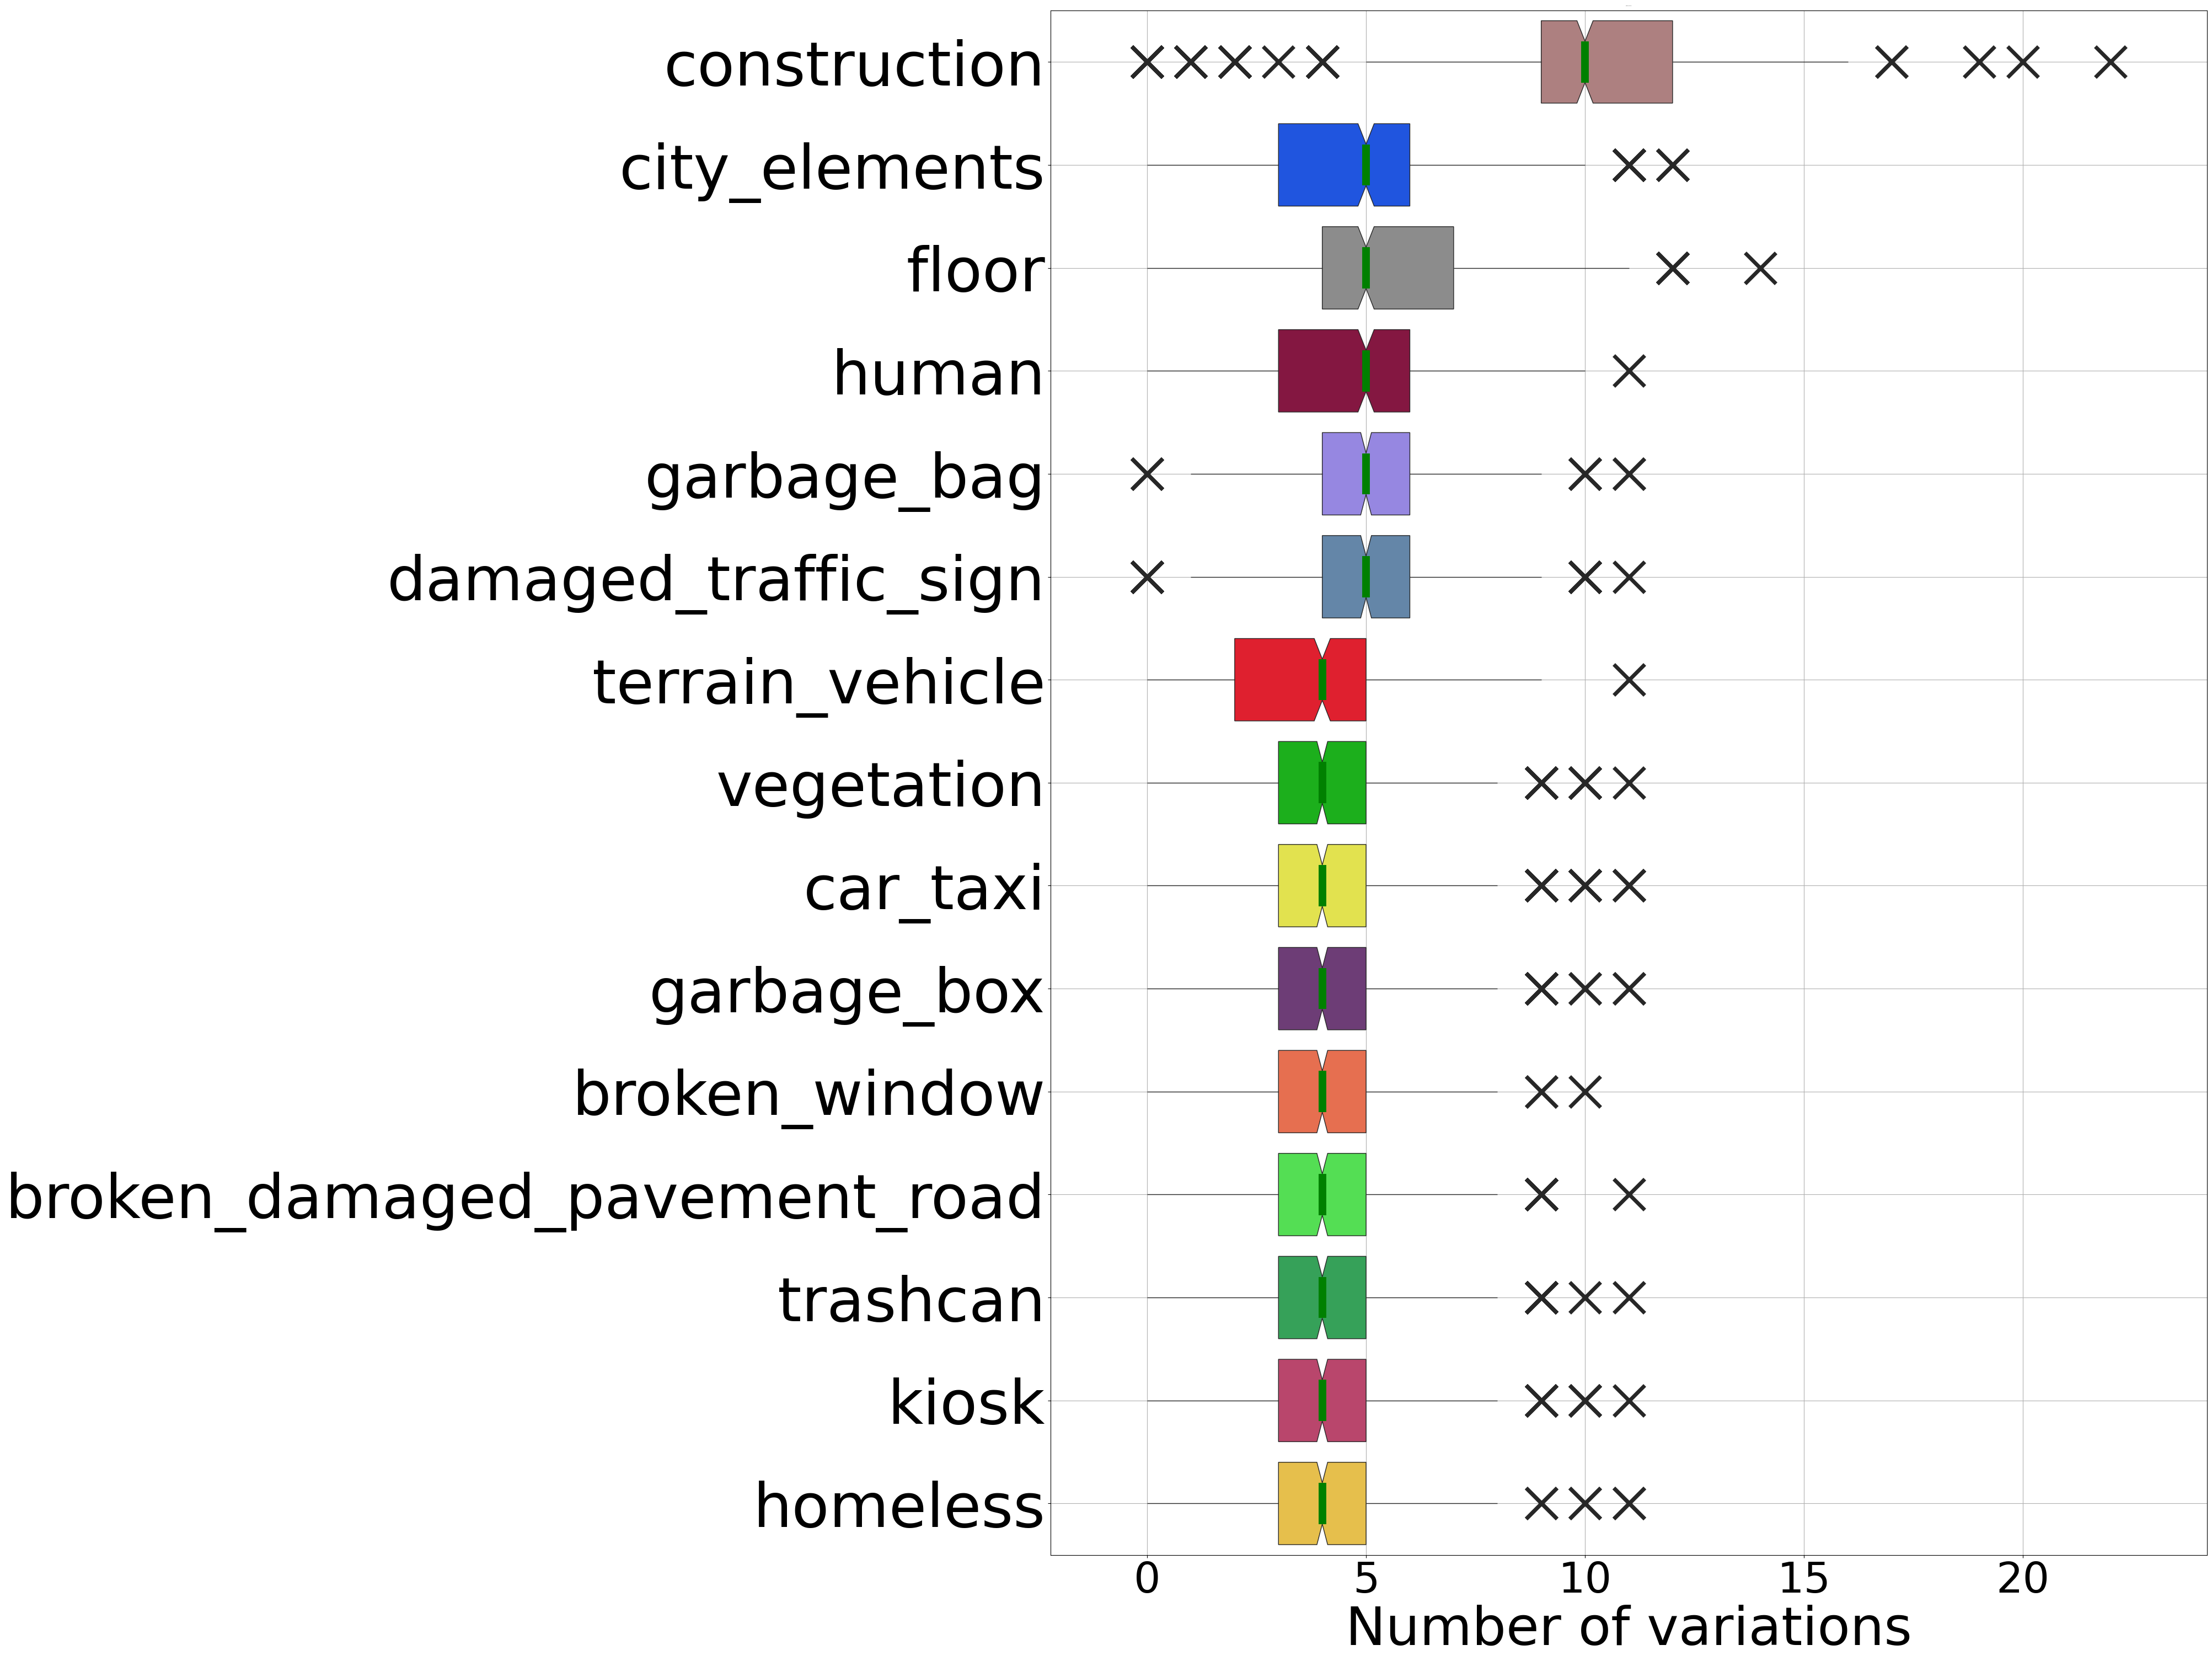

In [24]:
# Plot results
cf_analyzer.plot_variations(top_k=cfg.TOP_K_FEATURES, color_dict=uss.color_dict)